In [2]:
import numpy as np
import pandas as pd
import copy, math
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
np.random.seed(42)


In [3]:
data = fetch_california_housing(as_frame=True)
df = data.frame
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [4]:
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [5]:
features =['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
X= df[features].values
y= df['MedHouseVal'].values
X.shape, y.shape

((20640, 8), (20640,))

In [6]:
X_mean= X.mean(axis=0)
X_std = X.std(axis=0)
X_scaled =(X-X_mean)/X_std
X_scaled.mean(axis=0), X_scaled.std(axis=0)

(array([ 6.60969987e-17,  5.50808322e-18,  6.60969987e-17, -1.06030602e-16,
        -1.10161664e-17,  3.44255201e-18, -1.07958431e-15, -8.52651283e-15]),
 array([1., 1., 1., 1., 1., 1., 1., 1.]))

In [7]:
n_features = X_scaled.shape[1]
w=np.random.randn(n_features) * 0.01
b=0.0
w,b

(array([ 0.00496714, -0.00138264,  0.00647689,  0.0152303 , -0.00234153,
        -0.00234137,  0.01579213,  0.00767435]),
 0.0)

In [8]:
def predict(X,w,b):
  return X @ w +b
y_pred = predict(X_scaled,w,b)
y_pred[:5]

array([0.02084765, 0.01505303, 0.02118075, 0.01037024, 0.00721402])

In [9]:
def compute_cost(X,y,w,b):
 m =X.shape[0]
 cost=0.0
 for i in range(m):
   f_wb_i = np.dot(X[i],w)+b
   cost=cost +(f_wb_i-y[i])**2
 cost= cost/(2*m)
 return cost
compute_cost(X_scaled,y,w,b)

np.float64(2.8043727464635255)

In [10]:
def compute_gradient(X,y,w,b):
  m,n = X.shape
  dj_dw = np.zeros((n,))
  dj_db=0
  for i in range(m):
    err=(np.dot(X[i],w)+b) -y[i]
    for j in range(n):
      dj_dw[j]=dj_dw[j] + err * X[i,j]
    dj_db = dj_db+err
  dj_dw=dj_dw/m
  dj_db=dj_db/m
  return dj_db, dj_dw



In [11]:
def gradient_descent(X,y,w_in,b_in,cost_function,gradient_function,alpha,num_iters):
  J_history=[]
  w=copy.deepcopy(w_in)
  b=b_in
  for i in range(num_iters):
    dj_db,dj_dw = gradient_function(X,y,w,b)
    w=w-alpha *dj_dw
    b=b-alpha*dj_db
    if i<100000:
      J_history.append(cost_function(X,y,w,b))
    if i%math.ceil(num_iters /10) == 0:
      print(f"Iteration{i:4d}: Cost {J_history[-1]:8.2f}  ")
  return w,b,J_history


In [12]:
w_init = np.zeros(n_features)
b_init = 0.0

w, b, J_history = gradient_descent(X_scaled, y, w_init, b_init, compute_cost, compute_gradient, alpha=0.1, num_iters=800)
print(f"b,w found by gradient descent: {b:0.2f},{w} ")

Iteration   0: Cost     2.33  
Iteration  80: Cost     0.28  
Iteration 160: Cost     0.27  
Iteration 240: Cost     0.26  
Iteration 320: Cost     0.26  
Iteration 400: Cost     0.26  
Iteration 480: Cost     0.26  
Iteration 560: Cost     0.26  
Iteration 640: Cost     0.26  
Iteration 720: Cost     0.26  
b,w found by gradient descent: 2.07,[ 0.83253427  0.11948706 -0.27068098  0.30980287 -0.00427331 -0.03945063
 -0.89178748 -0.86276501] 


In [13]:
from sklearn.linear_model import LinearRegression

sklearn_model = LinearRegression()
sklearn_model.fit(X_scaled, y)

print("Your weights:", w)
print("Sklearn weights:", sklearn_model.coef_)
print()
print("Your bias:", b)
print("Sklearn bias:", sklearn_model.intercept_)

Your weights: [ 0.83253427  0.11948706 -0.27068098  0.30980287 -0.00427331 -0.03945063
 -0.89178748 -0.86276501]
Sklearn weights: [ 0.8296193   0.11875165 -0.26552688  0.30569623 -0.004503   -0.03932627
 -0.89988565 -0.870541  ]

Your bias: 2.068558169089138
Sklearn bias: 2.0685581690891386


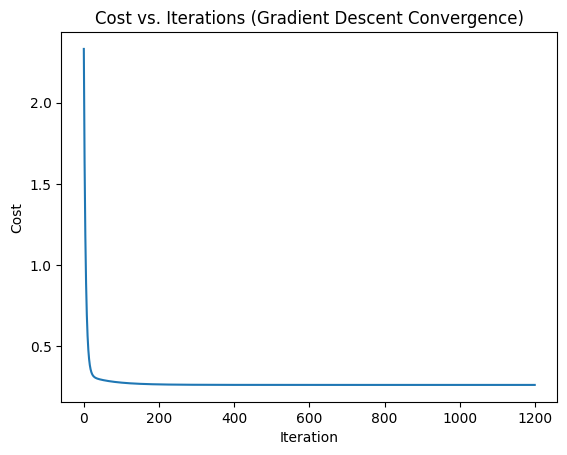

In [ ]:
plt.plot(J_history)
plt.xlabel('Iteration')
plt.ylabel('Cost')
plt.title('Cost vs. Iterations (Gradient Descent Convergence)')
plt.show()